The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


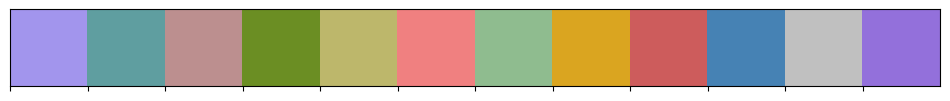

In [477]:
%load_ext autoreload
%autoreload 2
from utils.plotting import *
from results.results3 import *

colors = [
    ["#a295ed"],  # soft lavender
    ["#5F9EA0"],  # cadet blue
    ["#BC8F8F"],  # rosy brown
    ["#6B8E23"],  # olive drab
    ["#BDB76B"],  # dark khaki
    ["#F08080"],  # light coral
    ["#8FBC8F"],  # dark sea green
    ["#DAA520"],  # goldenrod
    ["#CD5C5C"],  # indian red
    ["#4682B4"],  # steel blue
    ["#C0C0C0"],  # silver gray
    ["#9370DB"],  # medium purple
]
sns.palplot([c[0] for c in colors])

In [478]:
# getting results
rel_path = "./results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000"

# dir_path_seeds = fsnet_ft_sup_trainsize7000_over_sublevel
# dir_path_seeds = fsnet_ft_sup_pen_trainsize7000_over_sublevel
# dir_path_seeds = fsnet_ft_sup_pen_trainsize7000_over_sublevel2
# dir_path_seeds = fsnet_ft_sup_pen_over_sublevel3 # OK 
# dir_path_seeds = fsnet_ft_sup_990_trainsize7000_over_sublevel
# dir_path_seeds = fsnet_ft_sup_pen_w100_trainsize7000_over_sublevel # OK
# dir_path_seeds = fsnet_ft_sup_pen_w100_ratio05_trainsize7000_over_nlabel # OK
# dir_path_seeds = fsnet_ft_sup_pen_w100_ratio05_trainsize7000_over_ckpt
# dir_path_seeds = mse_pen_w100_ratio05_trainsize800
# dir_path_seeds = fsnet_ft_sup_pen_w100_ratio05_trainsize7000_over_ckpt2
dir_path_seeds = main_ft_sup_pen_over_method

# collecting data
obj_mean = np.zeros_like(dir_path_seeds, dtype=float)
obj_max = np.zeros_like(dir_path_seeds, dtype=float)
eq_violation_l1_mean = np.zeros_like(dir_path_seeds, dtype=float)
eq_violation_l1_max = np.zeros_like(dir_path_seeds, dtype=float)
ineq_violation_l1_mean = np.zeros_like(dir_path_seeds, dtype=float)
ineq_violation_l1_max = np.zeros_like(dir_path_seeds, dtype=float)

batch_size = 256
for i in range(dir_path_seeds.shape[0]):  # over ckpt
    for j in range(dir_path_seeds.shape[1]):  # over seeds
        dir_path = os.path.join(
            rel_path, dir_path_seeds[i, j]
        )
        with open(os.path.join(dir_path, "results.pkl"), "rb") as f:
            print(dir_path)
            results = pickle.load(f)
            results_ = results['test_results']['batch_size_comparison'][batch_size]['metrics']
        obj_mean[i, j] = results_["objective"]
        obj_max[i, j] = results_["objective_max"]
        eq_violation_l1_mean[i, j] = results_["eq_violation_l1_mean"]
        eq_violation_l1_max[i, j] = results_["eq_violation_l1_max"]
        ineq_violation_l1_mean[i, j] = results_["ineq_violation_l1_mean"]
        ineq_violation_l1_max[i, j] = results_["ineq_violation_l1_max"]
        
# assuming you already have: dir_path_seeds, rel_path
num_baselines = dir_path_seeds.shape[0]
num_seeds = dir_path_seeds.shape[1]
print(num_baselines, num_seeds)

# read one file to know number of epochs
with open(os.path.join(rel_path, dir_path_seeds[0, 0], "results.pkl"), "rb") as f:
    results = pickle.load(f)
    num_epochs = len(results["val_history"])

# store [num_baselines, num_seeds, num_epochs]
obj_mean_epochs = np.zeros((num_baselines, num_seeds, num_epochs))

for i in range(num_baselines):  # over ckpt
    for j in range(num_seeds):  # over seed
        dir_path = os.path.join(rel_path, dir_path_seeds[i, j])
        with open(os.path.join(dir_path, "results.pkl"), "rb") as f:
            results = pickle.load(f)

./results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260118-225115_MLP_DC3_seed3_nepochs1000_lr0.0001_trainsize7000
./results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260118-230024_MLP_DC3_seed2_nepochs1000_lr0.0001_trainsize7000
./results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260118-222424_MLP_DC3_seed0_nepochs1000_lr0.0001_trainsize7000
./results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260118-223637_MLP_DC3_seed1_nepochs1000_lr0.0001_trainsize7000
./results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260118-225653_MLP_DC3_seed2_nepochs1000_lr0.0001_trainsize7000_finetune_20260118-184700_sup_seedpartial_model_230
./results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260118-230534_MLP_DC3_seed3_nepochs1000_lr0.0001_trainsize7000_finetune_20260118-184700_sup_seedpartial_model_230
./results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260118-223717_MLP_DC3_seed0_nepochs1000_lr0.0001_trainsize7000_fi

In [479]:
results['test_results']['batch_size_comparison'][batch_size]['metrics'].keys()

dict_keys(['merit_std', 'opt_gap_mean', 'ineq_violation_l1_max', 'eq_violation_max_mean', 'merit_min', 'eq_violation_l2_mean', 'opt_gap_min', 'solution_distance_max', 'ineq_violation_l2_mean', 'eq_violation_l1_mean', 'merit_mean', 'objective', 'ineq_violation_l1_mean', 'eq_violation_l2_max', 'eq_violation_l1_max', 'opt_gap_std', 'eq_violation_max_max', 'opt_gap_max', 'solution_distance_std', 'true_objective', 'ineq_violation_max_max', 'solution_distance_mean', 'objective_max', 'ineq_violation_max_mean', 'merit_max', 'ineq_violation_l2_max', 'total_time', 'avg_inference_time'])

In [480]:
def plot_metrics_grid(
    metrics,
    checkpoints,
    *,
    nrows=2,
    ncols=3,
    figsize=(16, 9),
    x_label="Checkpoint",
    y_label="Value",
    tight_layout=True,
    suptitle=None,
):
    """
    Plot multiple metrics as mean ± std bar plots in a grid (ggplot-style).

    Args:
        metrics: list of tuples (metric_data, metric_name, logy, palette)
            - metric_data: array-like, shape (num_checkpoints, num_seeds)
            - metric_name: str
            - logy: bool
            - palette: str or list (uses first if list)
        checkpoints: list/array of checkpoint labels
    """

    checkpoints = list(checkpoints)
    x = np.arange(len(checkpoints))
    width = 0.6

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.ravel(axes)

    panel_grey = "#EBEBEB"

    for idx, (metric, name, logy, palette) in enumerate(metrics):
        if idx >= len(axes):
            break
        ax = axes[idx]

        color = palette[0] if isinstance(palette, (list, tuple)) else palette

        metric = np.asarray(metric)

        means = np.nanmean(metric, axis=1)
        stds  = np.nanstd(metric, axis=1)

        # Panel style
        ax.set_facecolor(panel_grey)
        # ax.set_axisbelow(True)
        # ax.grid(True, axis="y", color="white", linewidth=1.2)
        ax.grid(False)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(1.0)

        # Bars with error bars
        ax.bar(
            x, means, width,
            yerr=stds,
            color=color,
            edgecolor="black",
            linewidth=1.6,
            capsize=6,
            error_kw=dict(ecolor="black", lw=1.6, capthick=1.6)
        )

        if logy:
            ax.set_yscale("log")

        # Labels
        ax.set_title(name, fontsize=11, fontweight="bold", pad=6)
        ax.set_xlabel(x_label, fontsize=11)
        ax.set_ylabel(y_label, fontsize=11)

        ax.set_xticks(x)
        ax.set_xticklabels([str(c) for c in checkpoints], fontsize=10)
        ax.tick_params(axis="y", labelsize=10)

    # Remove unused axes
    for ax in axes[len(metrics):]:
        ax.remove()

    if suptitle:
        fig.suptitle(suptitle, fontsize=14, fontweight="bold", y=1.02)

    if tight_layout:
        plt.tight_layout()

    plt.show()

In [481]:
# Define metrics and headers
metrics = [
    ("Obj Mean", obj_mean),
    ("Obj Max", obj_max),
    ("Eq Vio Mean", eq_violation_l1_mean),
    ("Eq Vio Max", eq_violation_l1_max),
    ("Ineq Vio Mean", ineq_violation_l1_mean),
    ("Ineq Vio Max", ineq_violation_l1_max),
]

# Print Header
header = f"{'Method':<8} | " + " | ".join([f"{name:<18}" for name, _ in metrics])
print(header)
print("-" * len(header))

# Print Rows (Method)
for i in range(num_baselines):
    row_str = f"{i:<8} | "
    for _, data in metrics:
        # Compute mean and std over seeds (axis 1)
        mu = np.mean(data[i])
        sigma = np.std(data[i])
        # Format as scientific notation
        if data is obj_mean or data is obj_max:
            row_str += f"{mu:.2f} ± {sigma:.2f}".ljust(18) + " | "
        else:
            row_str += f"{mu:.2e} ± {sigma:.2e}".ljust(18) + " | "
    print(row_str)

Method   | Obj Mean           | Obj Max            | Eq Vio Mean        | Eq Vio Max         | Ineq Vio Mean      | Ineq Vio Max      
--------------------------------------------------------------------------------------------------------------------------------------
0        | 1.17 ± 2.88        | 4.50 ± 2.88        | 2.94e-13 ± 4.45e-14 | 3.62e-13 ± 5.24e-14 | 2.12e-02 ± 1.55e-02 | 4.05e-01 ± 1.04e-01 | 
1        | -2.66 ± 0.05       | 0.51 ± 0.04        | 2.86e-13 ± 1.33e-15 | 3.55e-13 ± 5.38e-15 | 2.89e-02 ± 1.59e-02 | 4.93e-01 ± 1.17e-01 | 


In [482]:
def plot_metrics_grid(
    metrics_config,
    method_labels,
    *,
    nrows=2,
    ncols=3,
    figsize=(16, 10),
    x_label="Method",
    y_label="Value",
):
    """
    Plots a grid of means (horizontal lines) with error bars.
    """
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.ravel(axes)
    
    x = np.arange(len(method_labels))
    width = 0.6
    panel_grey = "#EBEBEB"

    for idx, (name, data, logy, color) in enumerate(metrics_config):
        if idx >= len(axes): break
        ax = axes[idx]
        
        # Data processing: Mean & Std over seeds (axis 1)
        data = np.asarray(data)
        means = np.mean(data, axis=1)
        stds = np.std(data, axis=1)

        # 1. Draw Error Bars (Whiskers only)
        ax.errorbar(
            x, means, yerr=stds,
            fmt='none',          # No marker or connecting lines
            ecolor="black",
            elinewidth=1.5,
            capsize=6,
            capthick=1.5,
            zorder=2
        )

        # 2. Draw Mean as a horizontal line (The "Single Bar")
        ax.hlines(
            means,
            xmin=x - width/2,
            xmax=x + width/2,
            colors=color,
            linewidth=5,         # Thicker for visibility
            zorder=3
        )
        
        # Formatting
        ax.set_facecolor(panel_grey)
        ax.grid(True, axis='y', color='white', linestyle='-', alpha=0.5, zorder=0)
        
        if logy:
            ax.set_yscale("log")
            
        ax.set_title(name, fontsize=11, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(method_labels)
        ax.set_xlabel(x_label)

    # Remove empty subplots
    for ax in axes[len(metrics_config):]:
        ax.remove()

    plt.tight_layout()
    plt.show()

# === Configuration (Same as before) ===
c_obj = "#9370DB"  
c_eq  = "#5F9EA0"  
c_ineq= "#C08081"  

metrics_to_plot = [
    ("Obj Mean",       obj_mean,               False, c_obj),
    ("Eq Vio Mean",    eq_violation_l1_mean,   False,  c_eq),
    ("Ineq Vio Mean",  ineq_violation_l1_mean, False,  c_ineq),
    ("Obj Max",        obj_max,                False, c_obj),
    ("Eq Vio Max",     eq_violation_l1_max,    False,  c_eq),
    ("Ineq Vio Max",   ineq_violation_l1_max,  False,  c_ineq),
]

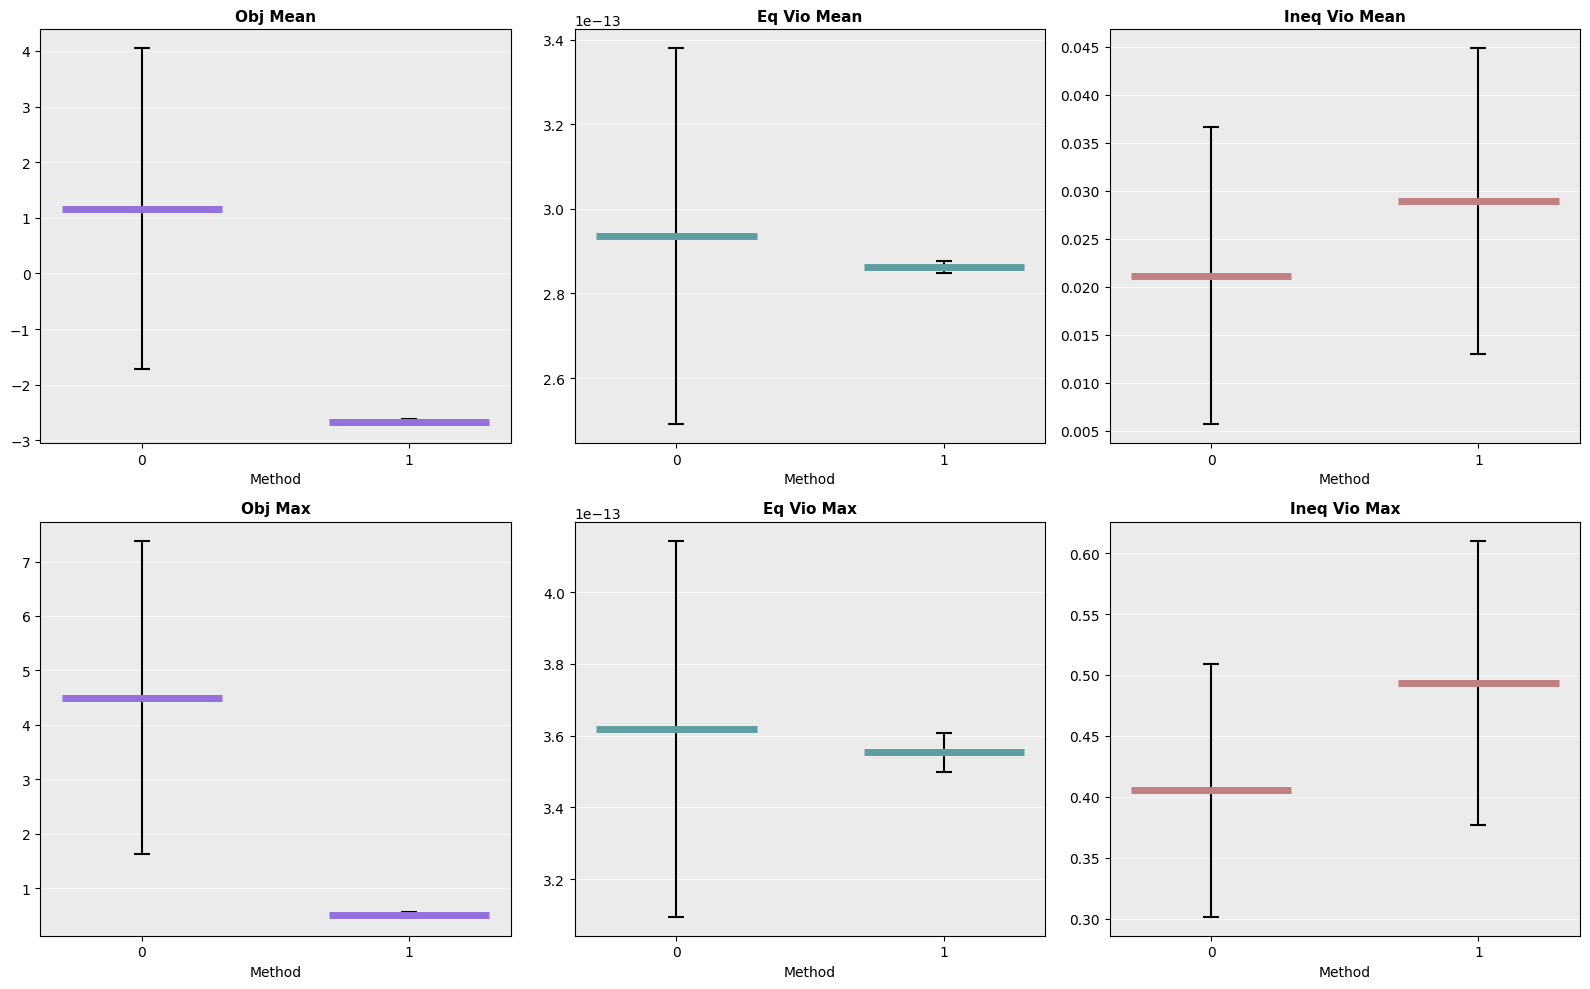

In [483]:
method_labels = [str(i) for i in range(num_baselines)]
# method_labels = ['baseline', 'penalty', 'data 100']
# method_labels = ['baseline', 'final', 'min merit']
# method_labels = ['baseline', 'subopt 0.5', 'subopt 3.0', 'subopt 4.0']
# method_labels = ['baseline', '50', '200', '800', '3000', '10000']

# === Plot ===
plot_metrics_grid(
    metrics_to_plot,
    method_labels,
    nrows=2, 
    ncols=3
)

In [484]:
# === define all metrics and plot settings ===
checkpoints = np.array([0.5, 1.5, 2.0, 3.0, 4.0])
select = [0, 1, 2, 3, 4, 5]

# plot_box_with_points(
#     [obj__mean[select]],
#     ["Opt Gap (Mean)"],
#     checkpoints,
#     x_label="Checkpoint",
#     title="",
#     log_scale_y=False,
#     figsize=(5, 4),
#     palette=colors[-1],
# )

metrics = [ 
    (obj_mean[select], "Opt Gap (Mean)", False, colors[-1]),
    (eq_violation_l1_mean[select], "Eq Violation L1 (Mean)", True, colors[1]),
    (ineq_violation_l1_mean[select], "Ineq Violation L1 (Mean)", True, colors[2]),
    (obj_max[select], "Opt Gap (Max)", False, colors[-1]),
    (eq_violation_l1_max[select], "Eq Violation L1 (Max)", True, colors[1]),
    (ineq_violation_l1_max[select], "Ineq Violation L1 (Max)", True, colors[2]),
]

plot_metrics_grid(
    metrics,
    checkpoints[select],
    nrows=2, ncols=3,
    figsize=(16, 9),
    x_label="Checkpoint",
    y_label="Value",
)

IndexError: index 2 is out of bounds for axis 0 with size 2

In [ ]:
# === define all metrics and plot settings ===
checkpoints = np.array([0, 400, 60])
select = [0, 2, 1]

# plot_box_with_points(
#     [opt_gap_mean[select]],
#     ["Opt Gap (Mean)"],
#     checkpoints,
#     x_label="Checkpoint",
#     title="",
#     log_scale_y=False,
#     figsize=(5, 4),
#     palette=colors[-1],
# )

metrics = [ 
    (opt_gap_mean[select], "Opt Gap (Mean)", False, colors[-1]),
    (eq_violation_l1_mean[select], "Eq Violation L1 (Mean)", True, colors[1]),
    (ineq_violation_l1_mean[select], "Ineq Violation L1 (Mean)", True, colors[2]),
    (opt_gap_max[select], "Opt Gap (Max)", False, colors[-1]),
    (eq_violation_l1_max[select], "Eq Violation L1 (Max)", True, colors[1]),
    (ineq_violation_l1_max[select], "Ineq Violation L1 (Max)", True, colors[2]),
]

plot_metrics_grid(
    metrics,
    checkpoints[select],
    nrows=2, ncols=3,
    figsize=(16, 9),
    x_label="Checkpoint",
    y_label="Value",
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Values (match your reference figure) ---
dose = np.array([0.5, 1.0, 2.0])

mean_OJ = np.array([13.2, 22.8, 26.1])
sd_OJ   = np.array([4.2,  3.8,  2.5])

mean_VC = np.array([8.1, 16.8, 26.3])
sd_VC   = np.array([2.7, 2.5,  4.6])

# --- Geometry ---
x = np.arange(len(dose))
width = 0.42  # wider, ggplot-like dodge

fig, ax = plt.subplots(figsize=(7, 5))

# --- ggplot-like panel + grid ---
ax.set_facecolor("#EBEBEB")          # ggplot2 grey panel
fig.patch.set_facecolor("white")
ax.grid(axis="y", color="white", linewidth=1.2)
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)

# --- Bars + error bars ---
oj = ax.bar(
    x - width/2, mean_OJ, width,
    yerr=sd_OJ, capsize=6,
    color="#F8766D", edgecolor="black", linewidth=1.8,
    error_kw=dict(ecolor="black", lw=1.8, capthick=1.8)
)
vc = ax.bar(
    x + width/2, mean_VC, width,
    yerr=sd_VC, capsize=6,
    color="#00BFC4", edgecolor="black", linewidth=1.8,
    error_kw=dict(ecolor="black", lw=1.8, capthick=1.8)
)

# --- Axes labels/ticks ---
ax.set_xlabel("dose", fontsize=13)
ax.set_ylabel("len", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([str(d) if d != 1.0 else "1" for d in dose], fontsize=11)
ax.tick_params(axis="y", labelsize=11)

# --- Spines (black frame like ggplot) ---
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.0)

# --- Legend on the right (title 'supp') ---
ax.legend(
    handles=[oj[0], vc[0]], labels=["OJ", "VC"], title="supp",
    frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5),
    fontsize=11, title_fontsize=12
)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (same structure as df2)
dose = [0.5, 1, 2]

len_OJ = [13.2, 22.8, 26.1]
sd_OJ  = [4.2, 3.8, 2.5]

len_VC = [8.1, 16.8, 26.3]
sd_VC  = [2.7, 2.5, 4.6]

x = np.arange(len(dose))
width = 0.4

fig, ax = plt.subplots(figsize=(7,5))

# ggplot colors
col_OJ = "#F8766D"
col_VC = "#00BFC4"

linewidth = 2.0

# Bars
ax.bar(x - width/2, len_OJ, width,
       color=col_OJ, edgecolor="black", linewidth=linewidth, label="OJ")

ax.bar(x + width/2, len_VC, width,
       color=col_VC, edgecolor="black", linewidth=linewidth, label="VC")

# Upper error bars only
ax.errorbar(x - width/2, len_OJ,
            yerr=[np.zeros(len(sd_OJ)), sd_OJ],
            fmt="none", ecolor="black", elinewidth=linewidth, capsize=10)

ax.errorbar(x + width/2, len_VC,
            yerr=[np.zeros(len(sd_VC)), sd_VC],
            fmt="none", ecolor="black", elinewidth=linewidth, capsize=10)

# Axes formatting
ax.set_xticks(x)
ax.set_xticklabels(dose)
ax.set_xlabel("dose")
ax.set_ylabel("len")

# ggplot-style panel
# ax.set_facecolor("#EBEBEB")
# ax.grid(True, axis="y", color="white", linewidth=1.2)
# ax.grid(False, axis="x")

for spine in ax.spines.values():
    spine.set_color("black")

ax.legend(title="supp", frameon=False)

plt.tight_layout()
plt.show()
